<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [2]:

#Create the dataframe
df = pd.read_csv('Lab11 Cleaned&Modified.csv')

#Display the top 10 records
df.head()


,Unnamed: 0,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,...,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat,Continent
0,0,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,8.0,Europe
1,1,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,...,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,8.0,Europe
2,2,7,"I am not primarily a developer, but I write co...",35-44 years old,"Employed, full-time",Remote,Apples,I don’t code outside of work,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)","Other online resources (e.g., videos, blogs, f...",...,NaN,NaN,NaN,NaN,NaN,Too long,Neither easy nor difficult,NaN,8.0,North America
3,3,9,I code primarily as a hobby,45-54 years old,"Employed, full-time",In-person,Apples,Hobby,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Books / Physical media;Other online resources ...,...,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor difficult,NaN,8.0,Europe
4,4,10,I am a developer by profession,35-44 years old,"Independent contractor, freelancer, or self-em...",Remote,Apples,Bootstrapping a business,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",On the job training;Other online resources (e....,...,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,8.0,Europe


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.

- 

- Постройте столбчатую диаграмму, чтобы визуализировать распределение респондентов по отраслям.

- Выделите любые заметные тенденции.


In [3]:
%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 6)

In [4]:
##Write your code here
#pd.crosstab(df['Industry'], df['Industry']).plot(kind='barh')

In [5]:
counts = df['Industry'].value_counts()
max_cat = counts.idxmax()  
min_cat = counts.idxmin()  

palette = []
for cat in counts.index:
    if cat == max_cat:
        palette.append('lightgreen')  
    elif cat == min_cat:
        palette.append('pink')    
    else:
        palette.append('skyblue')

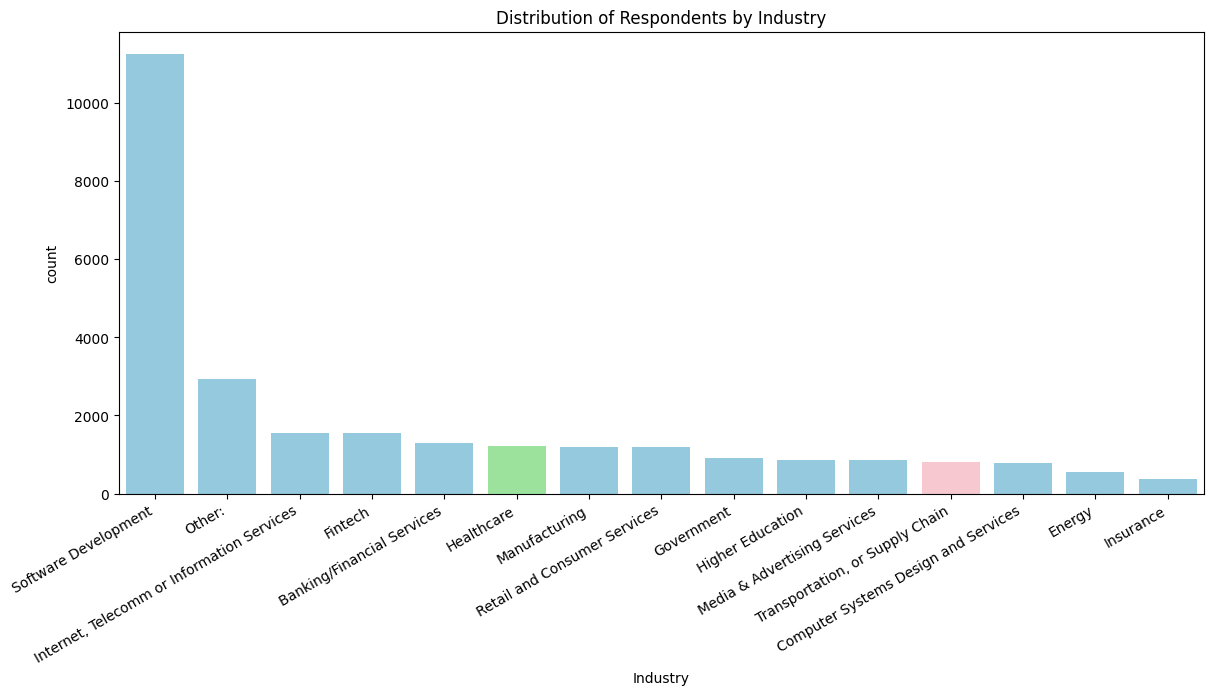

In [21]:
sns.countplot(df, x='Industry', order=df['Industry'].value_counts().index, palette=palette, hue='Industry',legend=False)
plt.title('Distribution of Respondents by Industry')
plt.xticks(rotation=30, ha='right');

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).

<br> Определите респондентов с крайне высокой годовой компенсацией.<br>

- Рассчитайте основные статистические показатели (среднее, медиана и стандартное отклонение) для ConvertedCompYearly.

- Определите значения компенсации, превышающие установленный порог (например, 3 стандартных отклонения выше среднего).

In [7]:
df['ConvertedCompYearly'].describe()

count    2.207900e+04
mean     8.478084e+04
std      1.445764e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.473200e+04
75%      1.074060e+05
max      1.381802e+07
Name: ConvertedCompYearly, dtype: float64

In [8]:
three = df['ConvertedCompYearly'].mean() + 3*df['ConvertedCompYearly'].std()

In [9]:
out=df[df['ConvertedCompYearly'] > three].index

<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.

  
<br>Определите выбросы в столбце ConvertedCompYearly, используя метод IQR.<br>

- Рассчитайте межквартильный размах (IQR).

- Определите верхние и нижние границы для выбросов.

- Подсчитайте и визуализируйте выбросы с помощью коробчатой диаграммы.

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


In [10]:
##Write your code here
q1 = df['ConvertedCompYearly'].quantile(0.25)
q3 = df['ConvertedCompYearly'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr
out1 = df[df['ConvertedCompYearly']>upper].index
out2 = df[df['ConvertedCompYearly']<lower].index

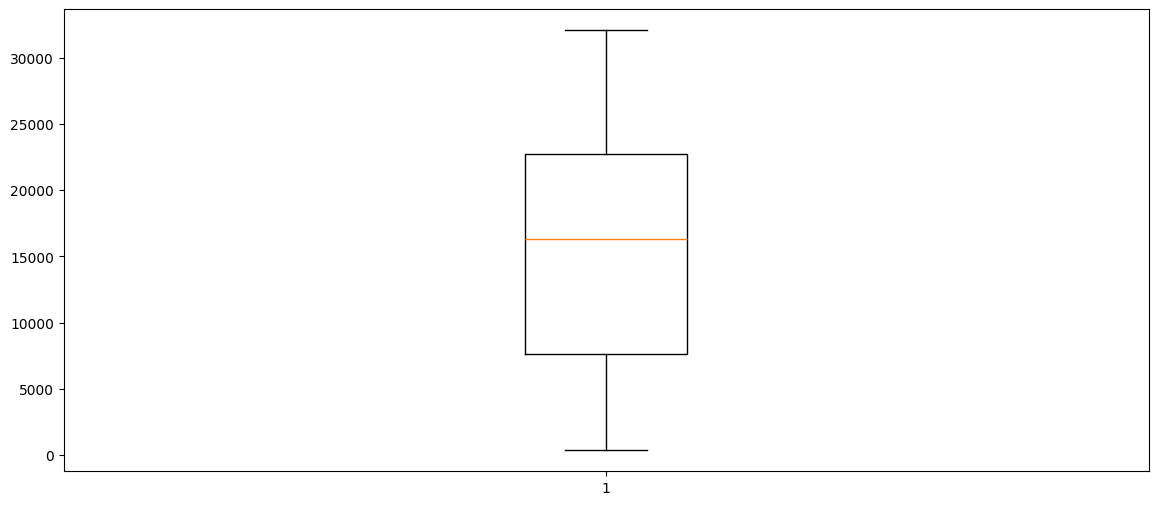

In [11]:
plt.boxplot(out1);

Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [12]:
##Write your code here
df_new=df.drop(out1)

In [13]:
df_new = df.drop(out)

In [14]:
df_new.shape

(46747, 116)

<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.

<br>Анализируйте корреляцию между Возрастом (преобразованным) и другими числовыми столбцами.<br>

- Отобразите столбец Возраст на приблизительные числовые значения.

- Вычислите корреляции между Возрастом и другими числовыми переменными.

- Визуализируйте матрицу корреляции.

In [15]:
df_new['Age'].unique()

<StringArray>
[   '35-44 years old',    '45-54 years old',    '25-34 years old',
    '18-24 years old',    '55-64 years old',  '65 years or older',
 'Under 18 years old',  'Prefer not to say']
Length: 8, dtype: str

In [16]:
##Write your code here
age_map = {'35-44 years old': (44+35)/2,
           'Under 18 years old' : 16,
           '18-24 years old' : (24+18)/2,
           '25-34 years old' : (34+25)/2,
           '45-54 years old' : (54+45)/2,
           '55-64 years old' : (64+55)/2,
           '65 years or older' : (65+80)/2}
df_new['Age'] = df_new['Age'].map(age_map)

In [17]:
df_new['Age']=df_new['Age'].dropna()

In [18]:
df_num = df_new.select_dtypes(include='number')

In [19]:
df_num.corr()['Age']

Unnamed: 0             0.001345
ResponseId             0.000563
Age                    1.000000
YearsCodePro           0.763546
CompTotal             -0.002804
WorkExp                0.853850
JobSatPoints_1        -0.032996
JobSatPoints_4        -0.076212
JobSatPoints_5        -0.102983
JobSatPoints_6        -0.052726
JobSatPoints_7        -0.084173
JobSatPoints_8        -0.048883
JobSatPoints_9        -0.083463
JobSatPoints_10       -0.115793
JobSatPoints_11       -0.108075
ConvertedCompYearly    0.339611
JobSat                 0.056063
Name: Age, dtype: float64

In [20]:
df_new.to_csv('Norm Age - Comp Outliers.csv')

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
